In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Phase 4 - Exploratory Data Analysis

# Objective: Explore customer behavior and characteristics associated with churn

### Key Questions:
# 1. What characteristics are associated with higher churn?
# 2. How do churned and retained customer differ?
# 3. what behavioral patterns may help explain why customers churn?

In [ ]:
df = pd.read_csv("../data/customer_churn_2026.csv")
print(df.shape)

In [22]:
## churned customers vs retained customers
numeric_cols =[
    'age',
    'tenure_months',
    'num_services',
    'monthly_charges',
    'total_charges',
    'payment_failures_last_year',
    'support_tickets_last_year',
    'avg_resolution_hours',
    'app_logins_per_month',
    'avg_session_minutes',
    'monthly_usage_hours',
    'days_since_last_login',
    'email_open_rate_pct',
    'satisfaction_score',
    'nps_score',
    'price_increase_last_year_pct',
    'discount_pct',
    'referrals_made'
]
df.groupby('churn')[numeric_cols].mean().round(2).T

churn,No,Yes
age,36.33,36.57
tenure_months,22.29,16.50
num_services,3.19,3.19
monthly_charges,21.06,20.32
total_charges,440.85,317.85
payment_failures_last_year,0.61,0.80
support_tickets_last_year,2.29,2.66
avg_resolution_hours,11.47,13.35
app_logins_per_month,16.32,15.33
avg_session_minutes,14.42,14.53


In [17]:
## satisfaction_score
df.groupby('churn')['satisfaction_score'].describe().round(2).T

churn,No,Yes
count,3915.00,1085.00
mean,8.32,7.77
std,1.08,1.15
min,4.00,4.70
25%,7.60,7.00
50%,8.40,7.80
75%,9.10,8.60
max,10.00,10.00


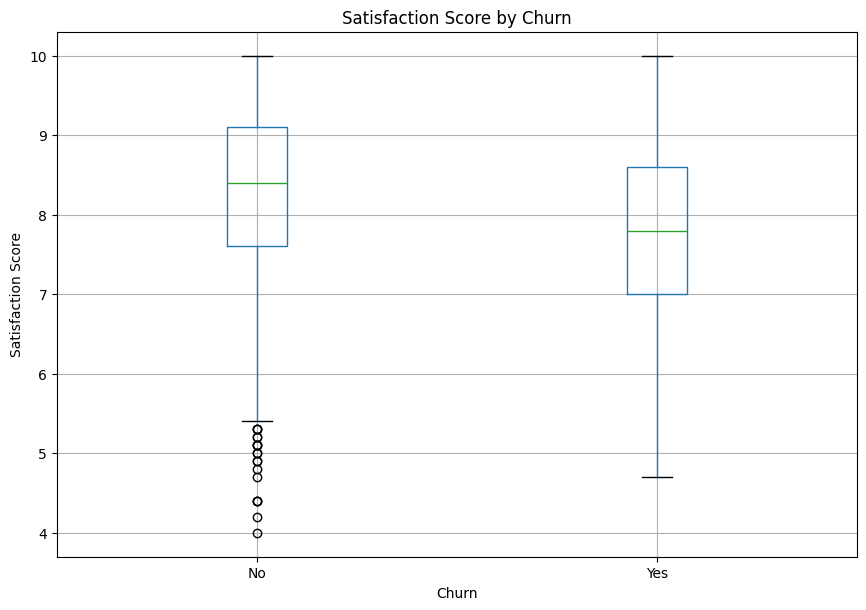

In [18]:
## Satisfaction scorce vs churn visualization

df.boxplot(column='satisfaction_score', by='churn', figsize=(10,7))

plt.title('Satisfaction Score by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Satisfaction Score')
plt.show()

## Note: Churned customers tend to have lower satisfaction scores than retained customers
## Those dots are outliers.They are legitimate customers whose satisfaction scores are unusually low compared with the rest of the retained population.
## Q: Why did some customers with unusually low satisfaction remain while others churned?

In [23]:
## ==========================================
## Descriptive Statistics (Outline Item 10)
## ==========================================
## Full comparison (mean, median, std, variance, Q1, Q3) for the six variables the outline
## specifically calls out: tenure, monthly charges, usage, support tickets, satisfaction,
## and login frequency. The table above already showed the mean for many variables - this
## adds what was missing (median, variance) and gives monthly_charges its own full
## breakdown, which it hadn't had yet.
##
## Caveat on total_charges and tenure_months in the table above: these two aren't
## independent signals. total_charges accumulates with tenure, so churned customers show
## lower total_charges mostly because they left earlier - not because they were lower-
## spending customers. Also, tenure_months for churned customers is tenure AT THE MOMENT
## THEY LEFT (a completed value), while for retained customers it's tenure SO FAR (still
## growing - some of these customers will still churn later). Comparing the two groups'
## tenure directly is a useful retrospective profile, but shouldn't be read as "long-tenure
## customers are safe."

outline_vars = {
    'tenure_months': 'Tenure (months)',
    'monthly_charges': 'Monthly Charges',
    'monthly_usage_hours': 'Usage (hours/month)',
    'support_tickets_last_year': 'Support Tickets',
    'satisfaction_score': 'Satisfaction Score',
    'app_logins_per_month': 'Login Frequency (logins/month)'
}

stats_rows = []
for col, label in outline_vars.items():
    for churn_status, group in df.groupby('churn')[col]:
        stats_rows.append({
            'Variable': label,
            'Churn': churn_status,
            'Mean': group.mean(),
            'Median': group.median(),
            'Std Dev': group.std(),
            'Variance': group.var(),
            'Q1': group.quantile(0.25),
            'Q3': group.quantile(0.75)
        })

descriptive_stats_summary = pd.DataFrame(stats_rows).round(2)
descriptive_stats_summary

,Variable,Churn,Mean,Median,Std Dev,Variance,Q1,Q3
0,Tenure (months),No,22.29,19.00,15.51,240.42,11.00,31.00
1,Tenure (months),Yes,16.50,14.00,12.83,164.60,7.00,22.00
2,Monthly Charges,No,21.06,19.66,9.47,89.59,13.58,26.88
3,Monthly Charges,Yes,20.32,18.63,9.19,84.44,12.74,26.63
4,Usage (hours/month),No,3.93,3.10,3.22,10.38,1.60,5.40
5,Usage (hours/month),Yes,3.75,2.80,3.29,10.80,1.40,5.10
6,Support Tickets,No,2.29,2.00,1.57,2.48,1.00,3.00
7,Support Tickets,Yes,2.66,2.00,1.69,2.85,1.00,4.00
8,Satisfaction Score,No,8.32,8.40,1.08,1.17,7.60,9.10
9,Satisfaction Score,Yes,7.77,7.80,1.15,1.32,7.00,8.60


In [24]:
## H₀: There is no monotonic association between satisfaction score and churn.
## H₁: There is a negative monotonic association between satisfaction score and churn.

from scipy.stats import spearmanr
correlation, p_value = spearmanr(
    df['satisfaction_score'],
    (df['churn'] == 'Yes').astype(int)
)

print("Spearman correlation:", round(correlation, 3))
print("p-value:", p_value)

## Customer satisfaction was significantly and negatively associated with churn (Spearman's ρ = −0.197, p < 0.001),
## indicating that customers with higher satisfaction tended to be less likely to churn.

Spearman correlation: -0.197
p-value: 7.423700944181174e-45


In [25]:
## Net Promoter Score
df.groupby('churn')['nps_score'].describe().round(2).T

churn,No,Yes
count,3915.00,1085.00
mean,8.15,7.56
std,1.62,1.76
min,1.00,2.00
25%,7.00,6.00
50%,8.00,8.00
75%,10.00,9.00
max,10.00,10.00


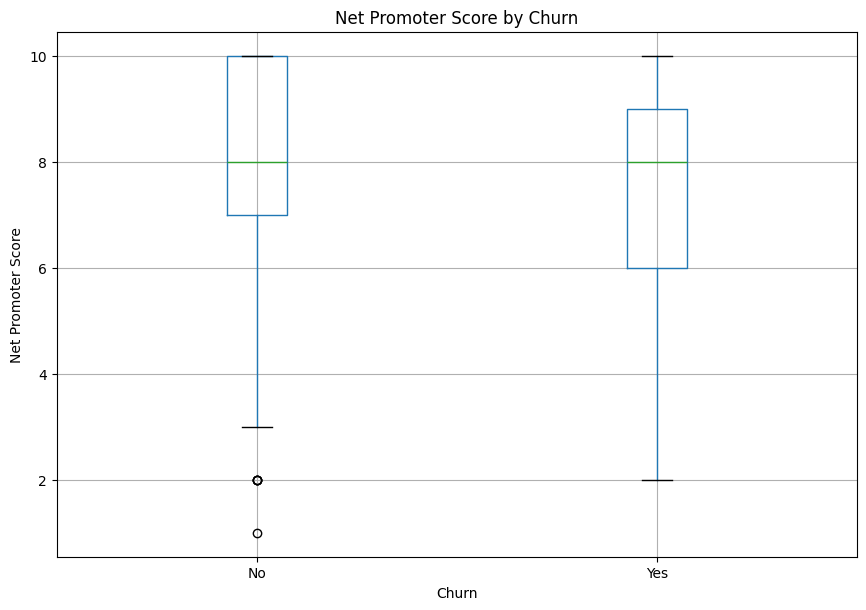

In [26]:
## NPS vs Churn Visualization

df.boxplot(column='nps_score', by='churn', figsize=(10,7))

plt.title('Net Promoter Score by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Net Promoter Score')
plt.show()

In [27]:
## H₀: There is no monotonic association between NPS score and churn.
## H₁: There is a monotonic association between NPS score and churn.
from scipy.stats import spearmanr
correlation, p_value = spearmanr(
    df['nps_score'],
    (df['churn'] == 'Yes').astype(int)
)
print("Spearman correlation:", round(correlation, 3))
print("p-value:", p_value)

Spearman correlation: -0.142
p-value: 6.810489559175747e-24


In [87]:
## tenure months
df.groupby('churn')['tenure_months'].describe().round(2).T

churn,No,Yes
count,3915.00,1085.00
mean,22.29,16.50
std,15.51,12.83
min,1.00,1.00
25%,11.00,7.00
50%,19.00,14.00
75%,31.00,22.00
max,84.00,84.00


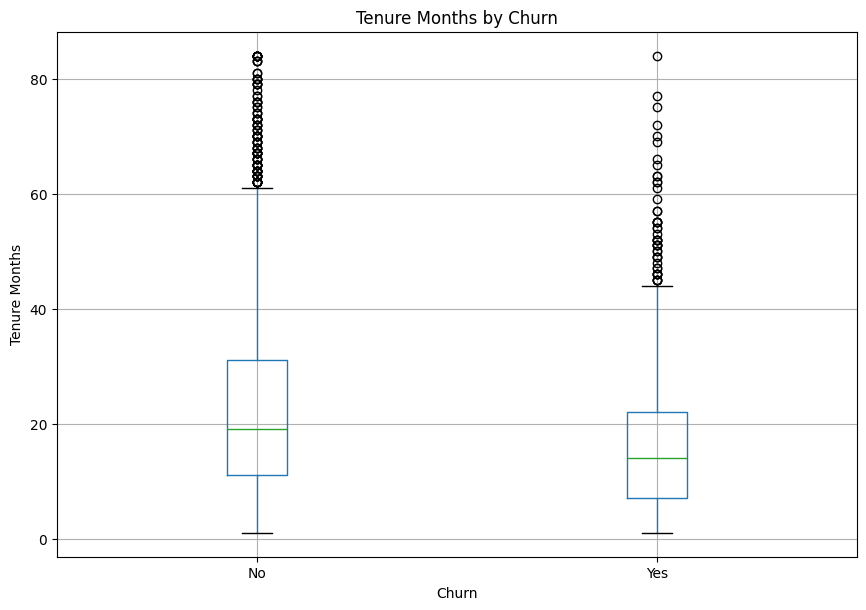

In [26]:
## tenure months vs churn rate visualization
df.boxplot(column='tenure_months', by='churn', figsize=(10,7))

plt.title('Tenure Months by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Tenure Months')
plt.show()

## Note: Newer customers appear substantially more vulnerable to churn.

In [92]:
## H₀: There is no monotonic association between tenure and churn.
## H₁: There is a negative monotonic association between tenure and churn.
from scipy.stats import spearmanr
correlation, p_value = spearmanr(
    df['tenure_months'],
    (df['churn'] == 'Yes').astype(int)
)
print("Spearman correlation:", round(correlation, 3))
print("p-value:", p_value)

## Customer tenure was significantly and negatively associated with churn (Spearman's ρ = −0.170, p < 0.001).
## Churned customers had shorter average tenure than retained customers (16.5 vs. 22.29 months),
## suggesting that newer customers may be more vulnerable to churn.

Spearman correlation: -0.17
p-value: 1.188671858188903e-33


In [28]:
## churn rate by number of payment failures

payment_failure_analysis = (
    df.groupby('payment_failures_last_year')['churn']
      .value_counts()
      .unstack(fill_value=0)
      .rename(columns={'Yes': 'churned_customers', 'No': 'retained_customers'})
)

payment_failure_analysis['total_customers'] = (
    payment_failure_analysis['retained_customers'] +
    payment_failure_analysis['churned_customers']
)

payment_failure_analysis['churn_rate_pct'] = (
    payment_failure_analysis['churned_customers'] /
    payment_failure_analysis['total_customers'] * 100
)

payment_failure_analysis.round(2)
## Note: higher payment failure frequency is associated with incresased churn

churn,retained_customers,churned_customers,total_customers,churn_rate_pct
payment_failures_last_year,,,,
0,2251,535,2786,19.20
1,1129,345,1474,23.41
2,382,127,509,24.95
3,119,55,174,31.61
4,26,15,41,36.59
5,8,8,16,50.00


Text(0, 0.5, 'Payment Failures')

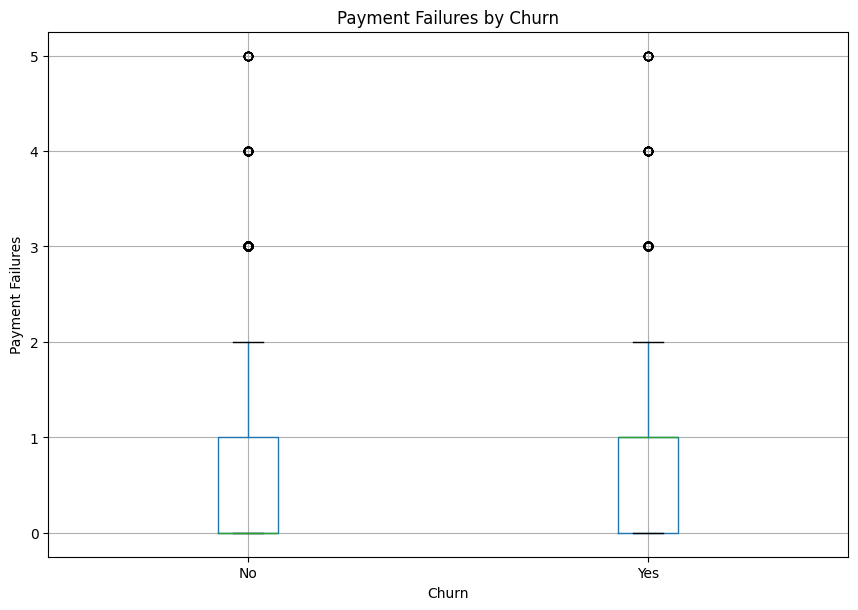

In [39]:
## Customers with more payment failures may be more likely to churn.
df.boxplot(column='payment_failures_last_year', by='churn', figsize=(10,7))

plt.title('Payment Failures by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Payment Failures')

In [29]:
## churn rate by number of payment failures

payment_failure_analysis = (
    df.groupby('payment_failures_last_year')['churn']
      .value_counts()
      .unstack(fill_value=0)
      .rename(columns={'Yes': 'churned_customers', 'No': 'retained_customers'})
)

payment_failure_analysis['total_customers'] = (
    payment_failure_analysis['retained_customers'] +
    payment_failure_analysis['churned_customers']
)

payment_failure_analysis['churn_rate_pct'] = (
    payment_failure_analysis['churned_customers'] /
    payment_failure_analysis['total_customers'] * 100
)

payment_failure_analysis.round(2)
## Note: higher payment failure frequency is associated with incresased churn

## Caveat: the >=4 (n=41) and especially the 5-failure (n=16) groups are small samples -
## their churn rates (36.6% and 50%) are noisy point estimates, not stable trend evidence.
## The clearer, more defensible pattern is the steady increase from 0 -> 1 -> 2 failures
## (19.2% -> 23.4% -> 25.0%), which rests on much larger group sizes.

churn,retained_customers,churned_customers,total_customers,churn_rate_pct
payment_failures_last_year,,,,
0,2251,535,2786,19.20
1,1129,345,1474,23.41
2,382,127,509,24.95
3,119,55,174,31.61
4,26,15,41,36.59
5,8,8,16,50.00


In [64]:
## days_since_last_login
df.groupby('churn')['days_since_last_login'].describe().round(2).T

churn,No,Yes
count,3915.00,1085.00
mean,9.03,9.95
std,8.29,9.30
min,0.00,0.00
25%,4.00,4.00
50%,7.00,8.00
75%,12.00,13.00
max,150.00,92.00


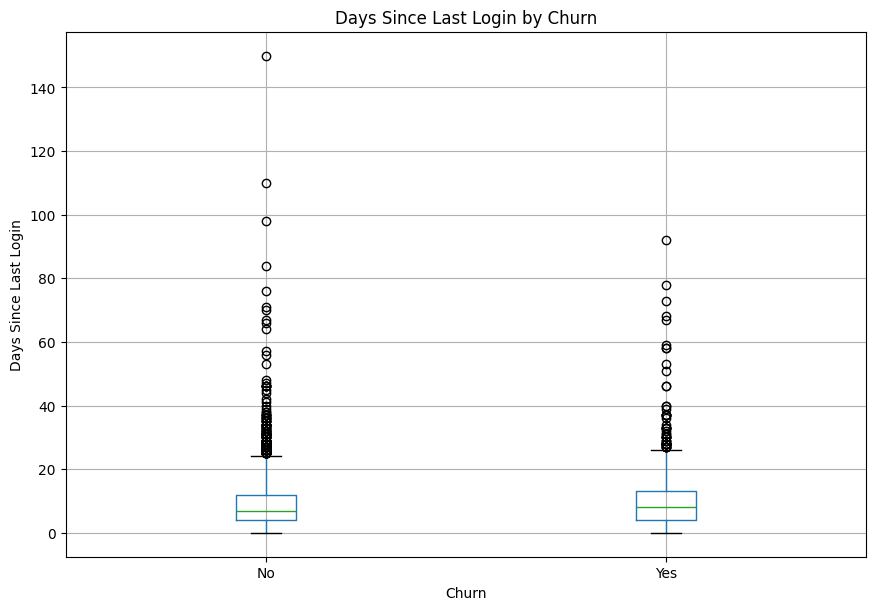

In [65]:
## days_since_last_login vs churn
df.boxplot(column='days_since_last_login', by='churn', figsize=(10,7))

plt.title('Days Since Last Login by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Days Since Last Login')
plt.show()

In [30]:
## H₀: There is no monotonic association between days since last login and churn.
## H₁: There is a positive monotonic association between days since last login and churn.
from scipy.stats import spearmanr

correlation, p_value = spearmanr(
    df['days_since_last_login'],
    (df['churn'] == 'Yes').astype(int)
)

print("Spearman correlation:", round(correlation, 3))
print("p-value:", round(p_value, 2))


## Step 1: Interpret the p-value
## Because: 0.01 < 0.05 so we reject the null hypothesis.
## So there is statistical evidence of an association between days since last login and churn.
## Step 2: Interpret the correlation
## because ρ is: 0.037. That's very close to zero, so the association is very weak.
## The direction is positive, meaning:
## As days since the last login increase, the likelihood of churn tends to increase slightly.
##But the effect is so small that days since last login by itself is not a strong predictor of churn in this dataset.

Spearman correlation: 0.037
p-value: 0.01


In [89]:
## app logins per month
df.groupby('churn')['app_logins_per_month'].describe().round(2).T

churn,No,Yes
count,3915.00,1085.00
mean,16.32,15.33
std,6.28,6.44
min,0.00,0.00
25%,12.00,11.00
50%,17.00,16.00
75%,21.00,20.00
max,36.00,36.00


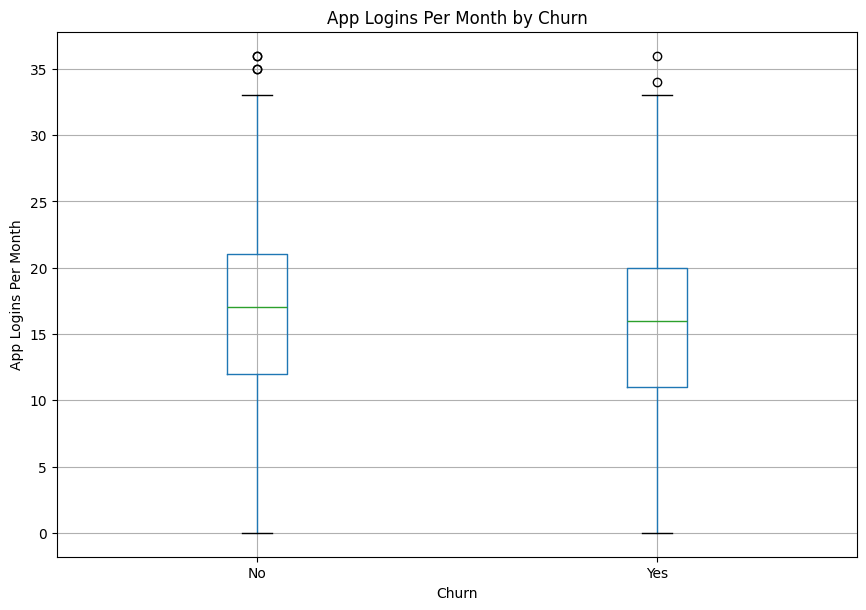

In [90]:
## app logins per moth vs churn

df.boxplot(column='app_logins_per_month', by='churn', figsize=(10,7))

plt.title('App Logins Per Month by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('App Logins Per Month')
plt.show()

In [91]:
## ## H₀: There is no monotonic association between app login frenquency and churn.
## H₁: There is a negative monotonic association between app login frenquency and churn.

from scipy.stats import spearmanr

correlation, p_value = spearmanr(
    df['app_logins_per_month'],
    (df['churn'] == 'Yes').astype(int)
)
print("Spearman correlation:", round(correlation, 3))
print("p-value:", p_value, )

## App login frequency was statistically associated with churn, but the association was very weak (Spearman's ρ = −0.065, p < 0.001).
## Churned customers averaged approximately one fewer app login per month than retained customers.

Spearman correlation: -0.065
p-value: 4.4694990860911005e-06


In [93]:
## monthly usage hours
df.groupby('churn')['monthly_usage_hours'].describe().round(2).T

churn,No,Yes
count,3915.00,1085.00
mean,3.93,3.75
std,3.22,3.29
min,0.00,0.00
25%,1.60,1.40
50%,3.10,2.80
75%,5.40,5.10
max,26.90,21.60


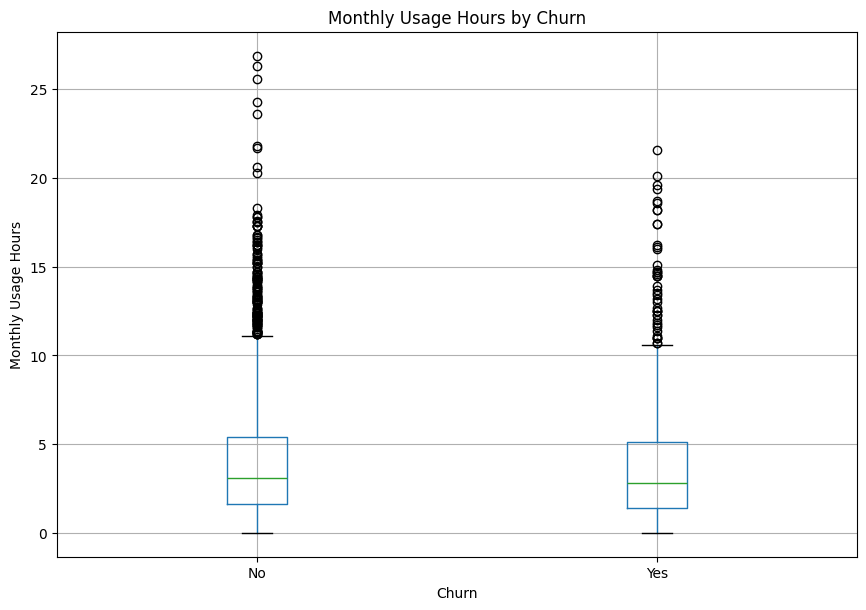

In [94]:
## monthly usage hours vs churn
df.boxplot(column='monthly_usage_hours', by='churn', figsize=(10,7))

plt.title('Monthly Usage Hours by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Usage Hours')
plt.show()

In [95]:
## H₀: There is no monotonic association between monthly usage and churn.
## H₁: There is a negative monotonic association between monthly usage and churn.

from scipy.stats import spearmanr

correlation, p_value = spearmanr(
    df['monthly_usage_hours'],
    (df['churn'] == 'Yes').astype(int)
)
print("Spearman correlation:", round(correlation, 3))
print("p-value:", p_value, )
## Spearman's correlation showed a statistically significant but very weak
## negative association between monthly usage hours and churn (ρ = -0.038, p = 0.0067).

## Although churned customers had slightly lower monthly usage,
## the very small correlation suggests that monthly usage alone
## has limited practical association with churn.

Spearman correlation: -0.038
p-value: 0.00672341567445134


In [96]:
## support tickets last year

df.groupby('churn')['support_tickets_last_year'].describe().round(2).T

churn,No,Yes
count,3915.00,1085.00
mean,2.29,2.66
std,1.57,1.69
min,0.00,0.00
25%,1.00,1.00
50%,2.00,2.00
75%,3.00,4.00
max,10.00,10.00


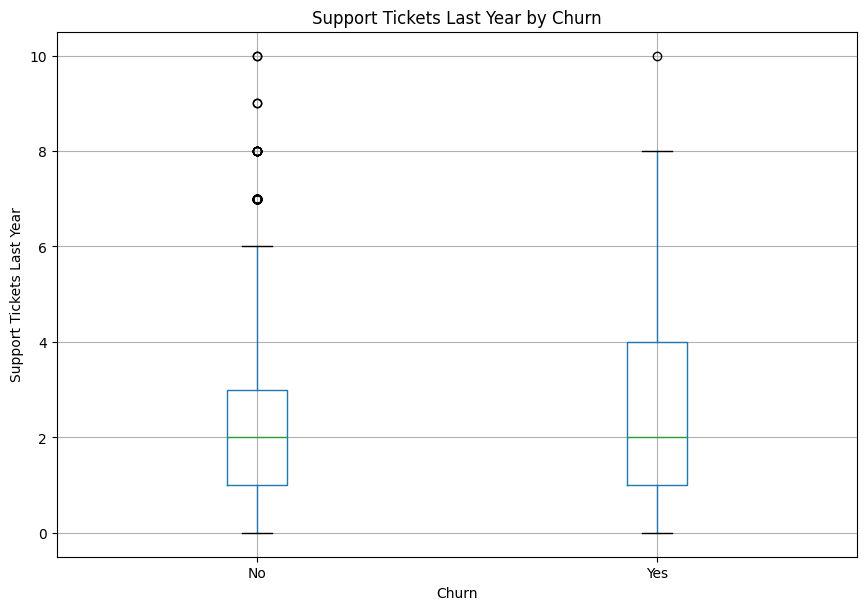

In [100]:
## support ticket last year vs churn
df.boxplot(column='support_tickets_last_year', by='churn', figsize=(10,7))
plt.title('Support Tickets Last Year by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Support Tickets Last Year')
plt.show()

In [101]:
## H₀: There is no monotonic association between support tickets last year and churn.
## H₁: There is a positive monotonic association between support tickets last year and churn.

from scipy.stats import spearmanr

correlation, p_value = spearmanr(
    df['support_tickets_last_year'],
    (df['churn'] == 'Yes').astype(int)
)
print("Spearman correlation:", round(correlation, 3))
print("p-value:", p_value, )

## Conclusion:
## Spearman's correlation showed a statistically significant but very weak
## positive association between support tickets last year and churn (ρ = 0.090, p < 0.001).

## Churned customers had a slightly higher average number of support tickets
## (2.66) than retained customers (2.29). However, the weak correlation
## suggests that support-ticket volume alone is not a strong predictor of churn.

Spearman correlation: 0.09
p-value: 1.848892441026131e-10


In [102]:
## avg resolution hours

df.groupby('churn')['avg_resolution_hours'].describe().round(2).T

churn,No,Yes
count,3915.00,1085.00
mean,11.47,13.35
std,8.21,9.12
min,0.50,0.50
25%,5.50,6.80
50%,9.60,11.70
75%,15.30,17.90
max,58.90,59.50


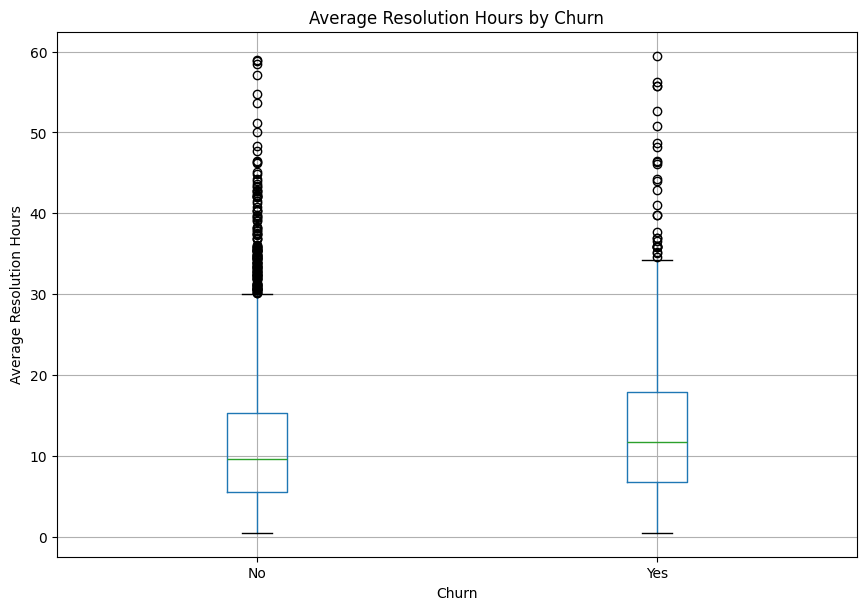

In [103]:
## avg resolution hours by churn
df.boxplot(column='avg_resolution_hours', by='churn', figsize=(10,7))

plt.title('Average Resolution Hours by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Average Resolution Hours')
plt.show()

In [20]:
## H₀: There is no monotonic association between average resolution hours and churn.
## H₁: There is a positive monotonic association between average resolution hours and churn.

from scipy.stats import spearmanr

correlation, p_value = spearmanr(
    df['avg_resolution_hours'],
    (df['churn'] == 'Yes').astype(int)
)
print("Spearman correlation:", round(correlation, 3))
print("p-value:", p_value,)

## ## Conclusion:
## Spearman's correlation showed a statistically significant but very weak
## positive association between average resolution hours and churn (ρ = 0.092, p < 0.001).

## Churned customers had higher average resolution times than retained
## customers (13.35 vs. 11.47 hours), suggesting that customers who
## experience longer support resolution times may be somewhat more likely to churn.

## However, the weak correlation indicates that resolution time alone is not a strong predictor of churn.

Spearman correlation: 0.092
p-value: 7.18993600796351e-11


In [14]:
## Step 11.1 phase 4: Probablity
df['days_since_last_login'].describe().round(2)

,days_since_last_login
count,5000.00
mean,9.23
std,8.53
min,0.00
25%,4.00
50%,7.00
75%,12.00
max,150.00


In [30]:
low_engagment = df['days_since_last_login'] > 12

print("Low engagement customers:", low_engagment.sum())
print("Percentage of customers:", round(low_engagment.mean()*100,2),"%")

## Low engagement was defined as more than 12 days since the customer's last login,
## corresponding approximately to the upper quartile of inactivity.

Low engagement customers: 1187
Percentage of customers: 23.74 %


In [31]:
## Out of ALL 5,000 customers, how many are BOTH low-engagement AND churned?
low_engagment_churned =(
    (df['days_since_last_login'] > 12) &
    (df['churn'] == 'Yes')
)

print("Percentage of Low engagment of churned customers:", round(low_engagment_churned.mean() * 100,2),"%")
print("Low engagement customers who churned:", low_engagment_churned.sum())

Percentage of Low engagment of churned customers: 5.88 %
Low engagement customers who churned: 294


In [44]:
## Among the 1,187 low-engagement customers, how many churned?
low_engagment_churned = (
    (df['days_since_last_login'] > 12) &
    (df['churn'] == 'Yes')).sum()
low_engagment_total = (df['days_since_last_login'] > 12).sum()

low_engagment_churned_pct = (
    low_engagment_churned / low_engagment_total * 100
)

print("P(churn | Low engagement):", round(low_engagment_churned_pct,2),"%")

## "Customers who have not logged in for more than 12 days show a moderately higher churn rate (24.77%) than the overall customer base (21.7%).
## This suggests that prolonged inactivity may serve as an early warning indicator.
## Businesses could prioritize these customers for proactive engagement, especially when inactivity occurs alongside other risk signals."

P(churn | Low engagement): 24.77 %


In [32]:
## Out of ALL 5,000 customers, how many are BOTH low-engagement AND churned?
low_engagment_churned =(
    (df['days_since_last_login'] > 12) &
    (df['churn'] == 'Yes')
)

print("P(Low engagement AND Churn) - joint probability over all customers:", round(low_engagment_churned.mean() * 100,2),"%")
print("Low engagement customers who churned:", low_engagment_churned.sum())

## This is the JOINT probability P(A and B) out of all 5,000 customers - not conditional on either group.
## The conditional probability P(churn | low engagement) is computed in the next cell.

P(Low engagement AND Churn) - joint probability over all customers: 5.88 %
Low engagement customers who churned: 294


In [33]:
## What is the churn probability for customers who experienced at least one payment failure?
payment_failure = df['payment_failures_last_year'] > 0

print("Payment failure customers:", payment_failure.sum())
print("Percentage of customers:", round(payment_failure.mean()*100,2),"%")


Payment failure customers: 2214
Percentage of customers: 44.28 %


In [23]:
## Out of ALL 5,000 customers, how many are BOTH experienced at least one payment failure AND churned?
payment_failure_churned = (
    (df['payment_failures_last_year'] > 0) &
    (df['churn'] == 'Yes')
)
print("Percentage of Payment failure customers who churned:", round(payment_failure_churned.mean()* 100,
2),"%")
print("Payment failure customers who churned:", payment_failure_churned.sum())

Percentage of Payment failure customers who churned: 11.0 %
Payment failure customers who churned: 550


In [6]:
## Out of ALL 2214 customers, what is the percentage that BOTH experienced at least one payment failure AND churned?

payment_failure_churned = (
    (df['payment_failures_last_year'] > 0) &
    (df['churn'] == 'Yes')).sum()
payment_failure_total = (df['payment_failures_last_year'] > 0).sum()

payment_failure_churned_pct = (
    payment_failure_churned / payment_failure_total * 100)
print("P(churn | Payment failure):", round(payment_failure_churned_pct,2),"%")

## Payment failures appear to be a potential churn risk indicator.
## Customers with at least one payment failure had a 24.84% churn rate, compared with 21.70% overall, a difference of 3.14 percentage points.

P(churn | Payment failure): 24.84 %


In [34]:
## Out of ALL 5,000 customers, how many are BOTH experienced at least one payment failure AND churned?
payment_failure_churned = (
    (df['payment_failures_last_year'] > 0) &
    (df['churn'] == 'Yes')
)
print("P(Payment failure AND Churn) - joint probability over all customers:", round(payment_failure_churned.mean()* 100,
2),"%")
print("Payment failure customers who churned:", payment_failure_churned.sum())

## This is the JOINT probability P(A and B) out of all 5,000 customers - not conditional on payment failure.
## The conditional probability P(churn | payment failure) is computed in the next cell.

P(Payment failure AND Churn) - joint probability over all customers: 11.0 %
Payment failure customers who churned: 550


In [17]:
## How many and  What is the churn probability for customers who have >= 4 tickets?
support_ticket = df['support_tickets_last_year'] >= 4

print("Support ticket customers:", support_ticket.sum())
print("Percentage of customers:", round(support_ticket.mean()*100,2),"%")

Support ticket customers: 1113
Percentage of customers: 22.26 %


In [24]:
## Out of ALL 5,000 customers, how many are BOTH have >= 4 tickets AND churned?

support_ticket_churned = (
    (df['support_tickets_last_year'] >= 4) &
    (df['churn'] == 'Yes')
)
print("Support ticket customers who churned:", support_ticket_churned.sum())
print("Percentage of churned customers:", round(support_ticket_churned.mean()*100,2),"%")



Support ticket customers who churned: 303
Percentage of churned customers: 6.06 %


In [28]:
## Out of ALL 1113 customers, what is the percentage that BOTH have >= 4 tickets AND churned?
support_ticket_churned = (
    (df['support_tickets_last_year'] >= 4) &
    (df['churn'] == 'Yes')).sum()
support_ticket_total = (df['support_tickets_last_year'] >= 4).sum()

support_ticket_churned_pct = (
    support_ticket_churned / support_ticket_total * 100)

print("P(churn | Support ticket):", round(support_ticket_churned_pct,2),"%")

## Customers with high support activity (≥4 support tickets in the last year) had a 27.22% churn rate,
## compared with the overall churn rate of 21.70%. This is a 5.52 percentage-point increase,
## suggesting that high support activity is associated with elevated churn risk.

P(churn | Support ticket): 27.22 %


In [ ]:
## Out of ALL 5,000 customers, how many are BOTH have >= 4 tickets AND churned?

support_ticket_churned = (
    (df['support_tickets_last_year'] >= 4) &
    (df['churn'] == 'Yes')
)
print("Support ticket customers who churned:", support_ticket_churned.sum())
print("P(>=4 tickets AND Churn) - joint probability over all customers:", round(support_ticket_churned.mean()*100,2),"%")

## This is the JOINT probability P(A and B) out of all 5,000 customers - not conditional on support ticket volume.
## The conditional probability P(churn | >=4 tickets) is computed in the next cell.

In [26]:
## How many and  What is the churn probability for customers with ≤12 months tenure?
# Tenure thresholds to test
thresholds = [3, 6, 9, 12, 18, 24]

for months in thresholds:
    short_tenure = df['tenure_months'] <= months

    print(f"Total short-tenure customers (<= {months} months):",
          short_tenure.sum())

    print(f"Percentage of customers (<= {months} months):",
          round(short_tenure.mean() * 100, 2), "%")

    print()

Total short-tenure customers (<= 3 months): 292
Percentage of customers (<= 3 months): 5.84 %

Total short-tenure customers (<= 6 months): 715
Percentage of customers (<= 6 months): 14.3 %

Total short-tenure customers (<= 9 months): 1212
Percentage of customers (<= 9 months): 24.24 %

Total short-tenure customers (<= 12 months): 1723
Percentage of customers (<= 12 months): 34.46 %

Total short-tenure customers (<= 18 months): 2646
Percentage of customers (<= 18 months): 52.92 %

Total short-tenure customers (<= 24 months): 3364
Percentage of customers (<= 24 months): 67.28 %



In [29]:
## Out of ALL 5,000 customers, how many BOTH have <=12 months tenure AND churned?
# Tenure thresholds to test
thresholds = [3, 6, 9, 12, 18, 24]

for months in thresholds:

    short_tenure_churned = (
        (df['tenure_months'] <= months) &
        (df['churn'] == 'Yes')
    )

    print(f"Short-tenure customers who churned (<= {months} months):",
          short_tenure_churned.sum())

    print(f"Percentage of ALL customers (<= {months} months & churned):",
          round(short_tenure_churned.mean() * 100, 2), "%")

    print()

Short-tenure customers who churned (<= 3 months): 105
Percentage of ALL customers (<= 3 months & churned): 2.1 %

Short-tenure customers who churned (<= 6 months): 234
Percentage of ALL customers (<= 6 months & churned): 4.68 %

Short-tenure customers who churned (<= 9 months): 369
Percentage of ALL customers (<= 9 months & churned): 7.38 %

Short-tenure customers who churned (<= 12 months): 502
Percentage of ALL customers (<= 12 months & churned): 10.04 %

Short-tenure customers who churned (<= 18 months): 723
Percentage of ALL customers (<= 18 months & churned): 14.46 %

Short-tenure customers who churned (<= 24 months): 857
Percentage of ALL customers (<= 24 months & churned): 17.14 %



In [28]:
# ==========================================
# Short-Tenure Churn Analysis
# ==========================================

overall_churn_rate = 21.70
thresholds = [3, 6, 9, 12, 18, 24]

for months in thresholds:

    # Total customers with short tenure
    short_tenure_total = (
        df['tenure_months'] <= months
    ).sum()

    # Short-tenure customers who churned
    short_tenure_churned = (
        (df['tenure_months'] <= months) &
        (df['churn'] == 'Yes')
    ).sum()

    # Churn rate among short-tenure customers who churned
    churn_rate = (
        short_tenure_churned / short_tenure_total * 100
    )

    # Relative churn risk
    relative_risk = (
        churn_rate / overall_churn_rate
    )

    # Percentage of all customers in the short-tenure group
    customer_percentage = (
        short_tenure_total / len(df) * 100
    )

    print(f"--- Tenure <= {months} months ---")
    print(f"Total customers: {short_tenure_total}")
    print(f"Customer percentage: {customer_percentage:.2f}%")
    print(f"Customers who churned: {short_tenure_churned}")
    print(f"Churn rate: {churn_rate:.2f}%")
    print(f"Relative churn risk: {relative_risk:.2f}x")
    print()

--- Tenure <= 3 months ---
Total customers: 292
Customer percentage: 5.84%
Customers who churned: 105
Churn rate: 35.96%
Relative churn risk: 1.66x

--- Tenure <= 6 months ---
Total customers: 715
Customer percentage: 14.30%
Customers who churned: 234
Churn rate: 32.73%
Relative churn risk: 1.51x

--- Tenure <= 9 months ---
Total customers: 1212
Customer percentage: 24.24%
Customers who churned: 369
Churn rate: 30.45%
Relative churn risk: 1.40x

--- Tenure <= 12 months ---
Total customers: 1723
Customer percentage: 34.46%
Customers who churned: 502
Churn rate: 29.14%
Relative churn risk: 1.34x

--- Tenure <= 18 months ---
Total customers: 2646
Customer percentage: 52.92%
Customers who churned: 723
Churn rate: 27.32%
Relative churn risk: 1.26x

--- Tenure <= 24 months ---
Total customers: 3364
Customer percentage: 67.28%
Customers who churned: 857
Churn rate: 25.48%
Relative churn risk: 1.17x



In [30]:
# ==========================================
# % of All Churners Captured
# ==========================================

total_churners = (df['churn'] == 'Yes').sum()

thresholds = [3, 6, 9, 12, 18, 24]

for months in thresholds:

    churned_in_group = (
        (df['tenure_months'] <= months) &
        (df['churn'] == 'Yes')
    ).sum()

    churners_captured = (
        churned_in_group / total_churners * 100
    )

    print(
        f"Churners captured (<= {months} months): "
        f"{churners_captured:.2f}%"
    )


    ## The 18-month threshold provides a stronger balance between churner capture, relative risk, and customer coverage,
    ## while the 24-month threshold is preferred if the primary objective is to capture at least 75% of churners.

Churners captured (<= 3 months): 9.68%
Churners captured (<= 6 months): 21.57%
Churners captured (<= 9 months): 34.01%
Churners captured (<= 12 months): 46.27%
Churners captured (<= 18 months): 66.64%
Churners captured (<= 24 months): 78.99%


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# Short-Tenure Threshold Analysis
# ============================================

thresholds = [3, 6, 9, 12, 18, 24]

# Overall churn rate
total_customers = len(df)
total_churners = (df['churn'] == 'Yes').sum()
overall_churn_rate = total_churners / total_customers * 100

results = []

for months in thresholds:

    # Customers within threshold
    customers_in_group = df['tenure_months'] <= months

    # Number of customers targeted
    customer_count = customers_in_group.sum()

    # % of all customers targeted
    customer_pct = customer_count / total_customers * 100

    # Customers in group who churned
    churned_in_group = (
        customers_in_group &
        (df['churn'] == 'Yes')
    ).sum()

    # Churn rate within threshold
    churn_rate = churned_in_group / customer_count * 100

    # Relative churn risk
    relative_risk = churn_rate / overall_churn_rate

    # % of all churners captured
    churners_captured = churned_in_group / total_churners * 100

    results.append({
        'Threshold (months)': months,
        'Customers': customer_count,
        '% Customers Targeted': customer_pct,
        'Churn Rate': churn_rate,
        'Relative Risk': relative_risk,
        '% Churners Captured': churners_captured
    })


# Create results table
threshold_table = pd.DataFrame(results)

# Round values for presentation
threshold_table = threshold_table.round({
    '% Customers Targeted': 2,
    'Churn Rate': 2,
    'Relative Risk': 2,
    '% Churners Captured': 2
})

threshold_table

,Threshold (months),Customers,% Customers Targeted,Churn Rate,Relative Risk,% Churners Captured
0,3,292,5.84,35.96,1.66,9.68
1,6,715,14.30,32.73,1.51,21.57
2,9,1212,24.24,30.45,1.40,34.01
3,12,1723,34.46,29.14,1.34,46.27
4,18,2646,52.92,27.32,1.26,66.64
5,24,3364,67.28,25.48,1.17,78.99


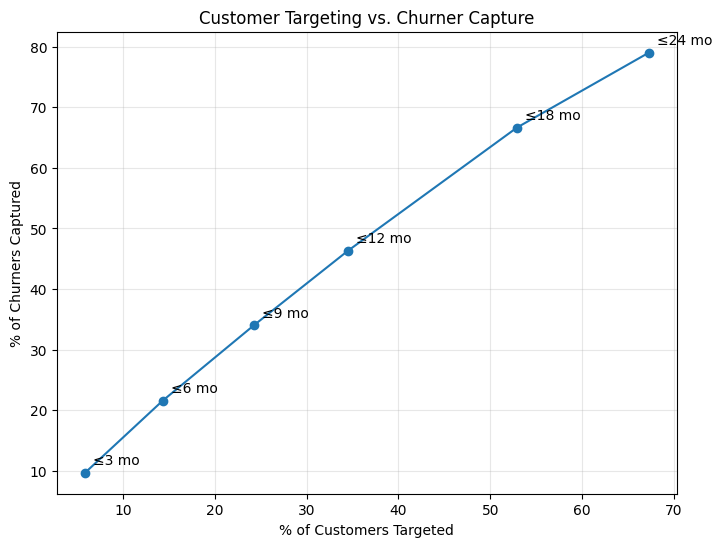

In [32]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_table['% Customers Targeted'],
    threshold_table['% Churners Captured'],
    marker='o'
)

# Label each point with its threshold
for _, row in threshold_table.iterrows():
    plt.annotate(
        f"≤{int(row['Threshold (months)'])} mo",
        (
            row['% Customers Targeted'],
            row['% Churners Captured']
        ),
        xytext=(6, 6),
        textcoords='offset points'
    )

plt.xlabel('% of Customers Targeted')
plt.ylabel('% of Churners Captured')
plt.title('Customer Targeting vs. Churner Capture')
plt.grid(True, alpha=0.3)

plt.show()

Note: "Historical analysis showed that customers with shorter tenure experienced elevated churn rates. Churn risk was highest among customers with ≤3 months of tenure (35.96%; 1.66× relative risk) and gradually declined as the tenure threshold increased. Although the ≤18-month segment captured 66.64% of historical churners, this measure reflects customers' tenure at the time of observed churn and therefore should not be interpreted as a prospective early-warning capture rate.

In [35]:
## ==========================================
## Summary: Outline Item 11 - Probability & Conditional Analysis
## ==========================================
## The outline asks for P(Churn), P(Churn | Low Engagement), P(Churn | Payment Failure),
## P(Churn | High Support Activity), and P(Churn | Short Tenure). All five were computed
## above across several cells - this consolidates them into one answer table.
## "Short tenure" is defined here as <=12 months (the first-year mark); the full threshold
## sweep (<=3 to <=24 months) above remains the more complete answer - this is the
## single-number version the outline is asking for.

overall_churn_pct = (df['churn'] == 'Yes').mean() * 100

def conditional_churn_rate(condition):
    return (df.loc[condition, 'churn'] == 'Yes').mean() * 100

probability_summary = pd.DataFrame([
    {'Definition': 'Overall',               'Condition': 'All customers',                 'P(Churn) %': overall_churn_pct},
    {'Definition': 'Low Engagement',        'Condition': 'days_since_last_login > 12',    'P(Churn) %': conditional_churn_rate(df['days_since_last_login'] > 12)},
    {'Definition': 'Payment Failure',       'Condition': 'payment_failures_last_year > 0','P(Churn) %': conditional_churn_rate(df['payment_failures_last_year'] > 0)},
    {'Definition': 'High Support Activity', 'Condition': 'support_tickets_last_year >= 4','P(Churn) %': conditional_churn_rate(df['support_tickets_last_year'] >= 4)},
    {'Definition': 'Short Tenure',          'Condition': 'tenure_months <= 12',           'P(Churn) %': conditional_churn_rate(df['tenure_months'] <= 12)},
])

probability_summary['P(Churn) %'] = probability_summary['P(Churn) %'].round(2)
probability_summary['Lift vs. Overall'] = (probability_summary['P(Churn) %'] / overall_churn_pct).round(2)
probability_summary

,Definition,Condition,P(Churn) %,Lift vs. Overall
0,Overall,All customers,21.70,1.00
1,Low Engagement,days_since_last_login > 12,24.77,1.14
2,Payment Failure,payment_failures_last_year > 0,24.84,1.14
3,High Support Activity,support_tickets_last_year >= 4,27.22,1.25
4,Short Tenure,tenure_months <= 12,29.14,1.34


In [36]:
## ==========================================
## Categorical / Customer-Characteristic Variables vs. Churn (Outline Item 9)
## ==========================================
## The sections above covered engagement/experience variables (logins, usage, tickets,
## satisfaction, NPS) in depth, but the categorical "customer characteristics" side of
## Item 9 hadn't been tested - contract_type, plan_tier, service_segment, signup_channel,
## primary_device, payment_method, has_family_plan, auto_pay, discount_offered, and
## competitor_offer_received. This mirrors the churn-by-segment tables already built in
## SQL (Phase 3), adding a chi-square significance test and a churn-rate bar chart for each.

from scipy.stats import chi2_contingency

def churn_by_category(data, column):
    """Crosstab of churn by a categorical column, with churn rate and a chi-square test of independence."""
    ct = pd.crosstab(data[column], data['churn'])
    ct['total'] = ct['Yes'] + ct['No']
    ct['churn_rate_pct'] = (ct['Yes'] / ct['total'] * 100).round(2)
    ct = ct.sort_values('churn_rate_pct', ascending=False)

    chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(data[column], data['churn']))
    min_expected = expected.min()

    print(f"--- {column} ---")
    print(ct)
    print(f"\nChi-square = {chi2:.2f}, p-value = {p_value:.4g}, dof = {dof}")
    if min_expected < 5:
        print(f"WARNING: smallest expected cell count is {min_expected:.1f} (<5) - chi-square result may be unreliable.")
    print()

    return ct


def plot_churn_rate_by_category(ct, column, overall_rate):
    ax = ct['churn_rate_pct'].plot(kind='bar', figsize=(8, 5), color='steelblue')
    ax.axhline(overall_rate, color='red', linestyle='--', label=f'Overall churn rate ({overall_rate:.1f}%)')
    plt.title(f'Churn Rate by {column}')
    plt.xlabel(column)
    plt.ylabel('Churn Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()


overall_churn_rate = (df['churn'] == 'Yes').mean() * 100
print(f"Overall churn rate: {overall_churn_rate:.2f}%")

Overall churn rate: 21.70%


--- contract_type ---
churn             No  Yes  total  churn_rate_pct
contract_type                                   
Month-to-month  1866  841   2707           31.07
Annual          1385  208   1593           13.06
Two year         664   36    700            5.14

Chi-square = 322.78, p-value = 8.116e-71, dof = 2



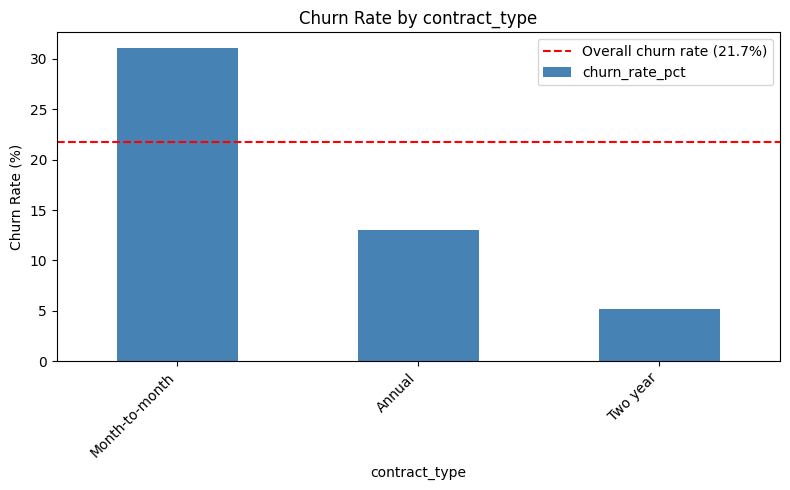

--- plan_tier ---
churn        No  Yes  total  churn_rate_pct
plan_tier                                  
Basic      1111  358   1469           24.37
Plus        843  235   1078           21.80
Standard   1351  351   1702           20.62
Premium     610  141    751           18.77

Chi-square = 11.12, p-value = 0.01112, dof = 3



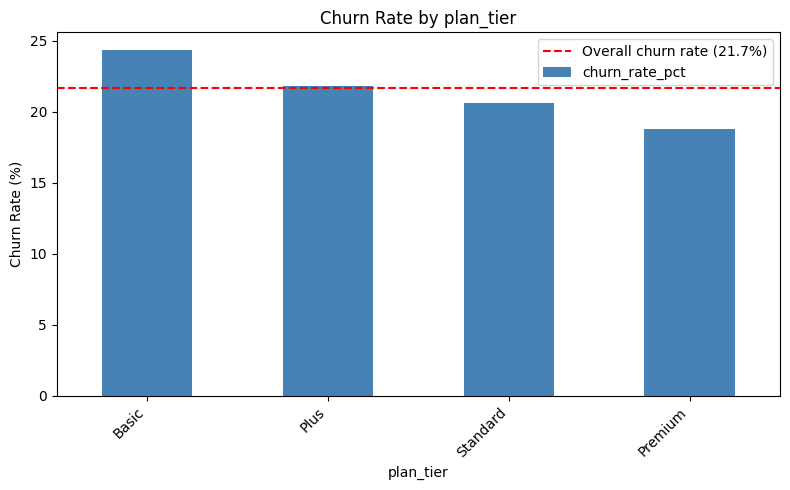

--- service_segment ---
churn             No  Yes  total  churn_rate_pct
service_segment                                 
Fintech          729  216    945           22.86
Fitness          425  125    550           22.73
News & Media     350  101    451           22.39
Streaming        991  282   1273           22.15
Productivity     617  168    785           21.40
Cloud Storage    466  112    578           19.38
Gaming           337   81    418           19.38

Chi-square = 4.57, p-value = 0.5999, dof = 6



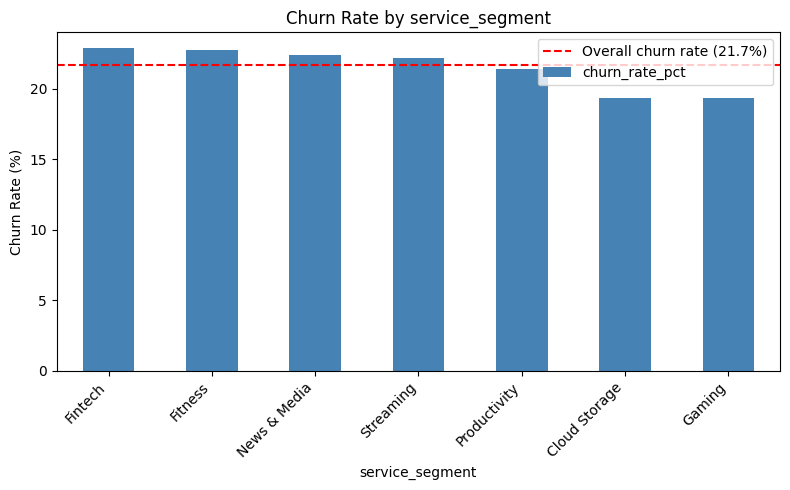

--- signup_channel ---
churn             No  Yes  total  churn_rate_pct
signup_channel                                  
Influencer       349  109    458           23.80
Referral         563  166    729           22.77
Paid Social      936  273   1209           22.58
App Store        744  204    948           21.52
Organic Search  1006  264   1270           20.79
Email Campaign   317   69    386           17.88

Chi-square = 6.20, p-value = 0.2877, dof = 5



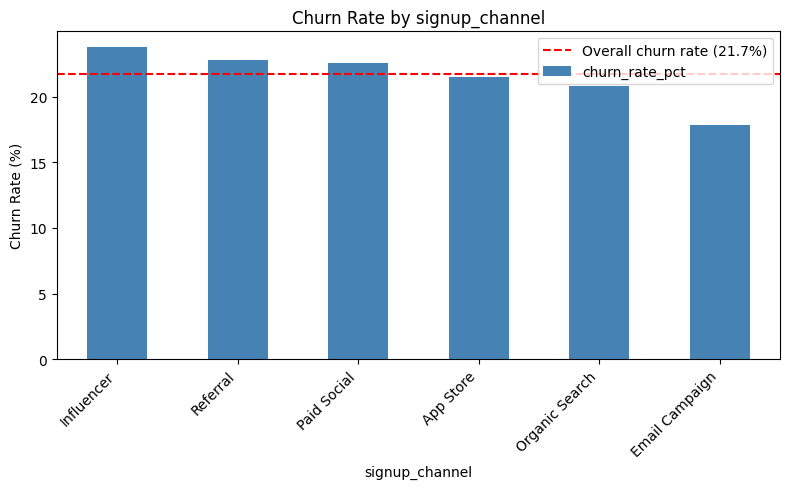

--- primary_device ---
churn             No  Yes  total  churn_rate_pct
primary_device                                  
Smart TV         328  124    452           27.43
Desktop         1007  286   1293           22.12
Tablet           365  100    465           21.51
Mobile          2215  575   2790           20.61

Chi-square = 10.84, p-value = 0.01261, dof = 3



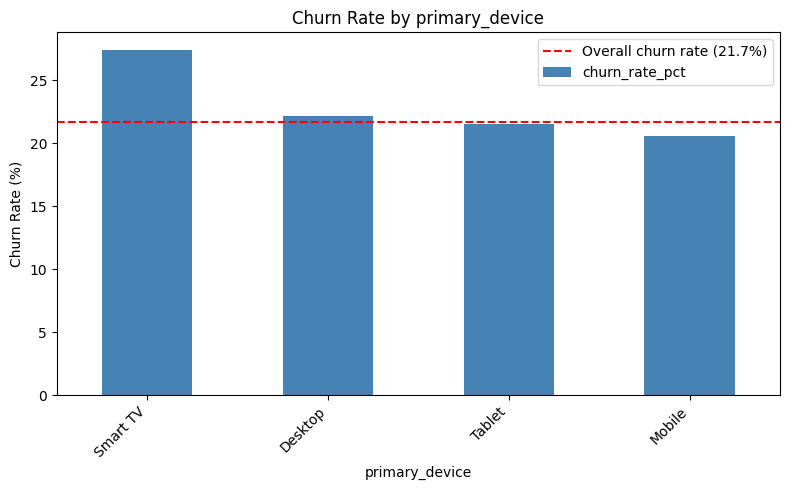

--- payment_method ---
churn                     No  Yes  total  churn_rate_pct
payment_method                                          
Digital wallet           618  190    808           23.51
UPI / Instant transfer   788  230   1018           22.59
Debit card               677  193    870           22.18
Credit card             1226  329   1555           21.16
Bank transfer            370   92    462           19.91
Buy now pay later        236   51    287           17.77

Chi-square = 5.91, p-value = 0.315, dof = 5



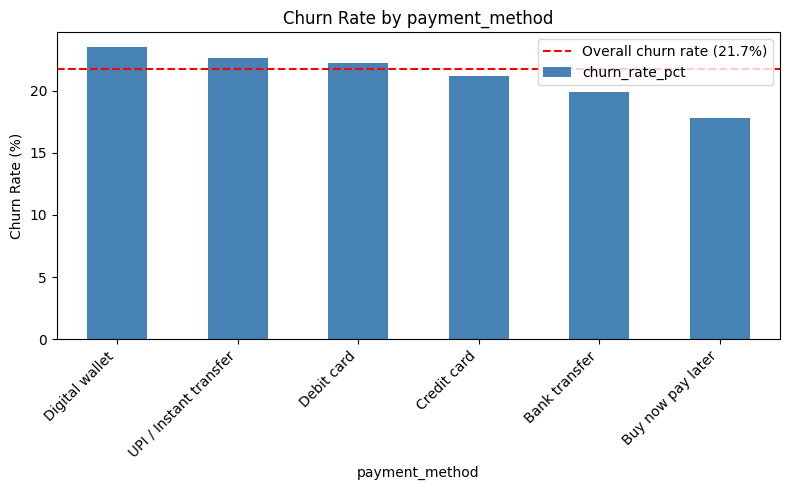

--- has_family_plan ---
churn              No  Yes  total  churn_rate_pct
has_family_plan                                  
True              940  267   1207           22.12
False            2975  818   3793           21.57

Chi-square = 0.13, p-value = 0.7134, dof = 1



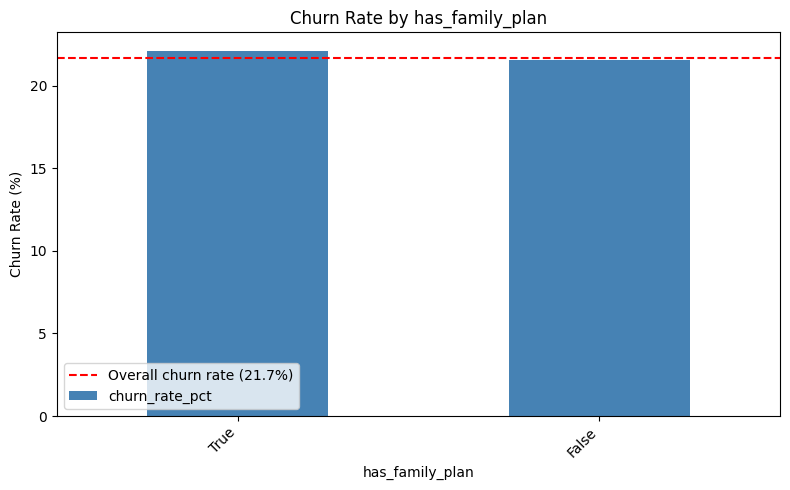

--- auto_pay ---
churn       No  Yes  total  churn_rate_pct
auto_pay                                  
False     1219  506   1725           29.33
True      2696  579   3275           17.68

Chi-square = 89.63, p-value = 2.872e-21, dof = 1



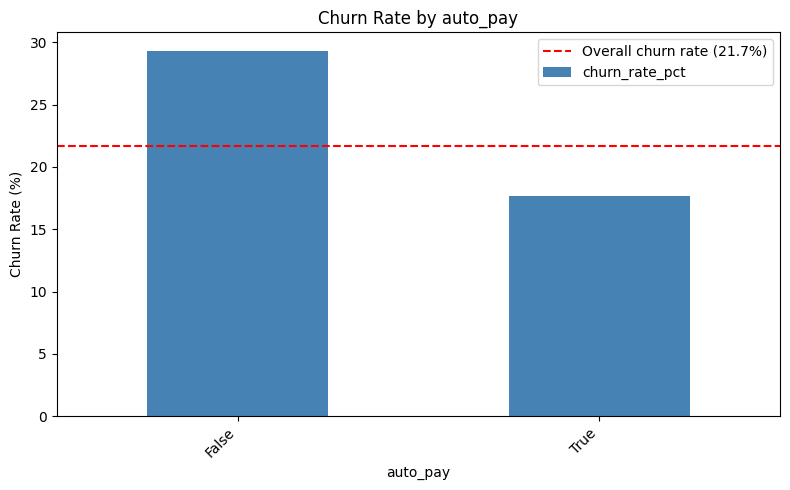

--- discount_offered ---
churn               No  Yes  total  churn_rate_pct
discount_offered                                  
False             2851  812   3663           22.17
True              1064  273   1337           20.42

Chi-square = 1.66, p-value = 0.1974, dof = 1



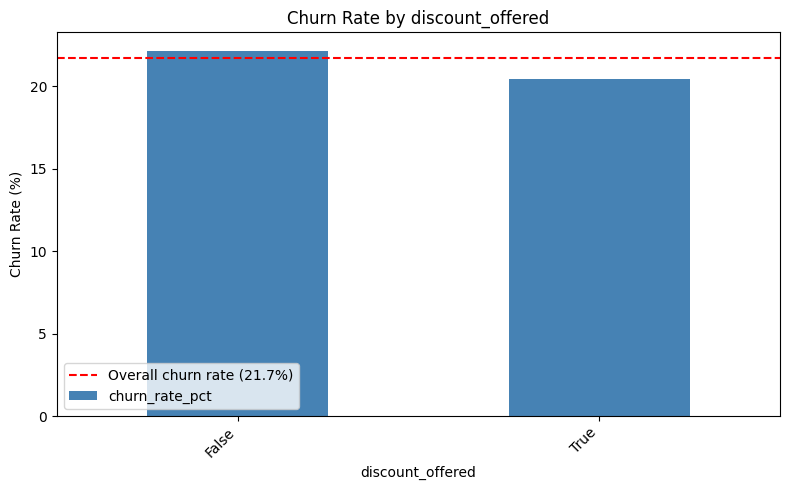

--- competitor_offer_received ---
churn                        No  Yes  total  churn_rate_pct
competitor_offer_received                                  
True                       1376  539   1915           28.15
False                      2539  546   3085           17.70

Chi-square = 75.29, p-value = 4.061e-18, dof = 1



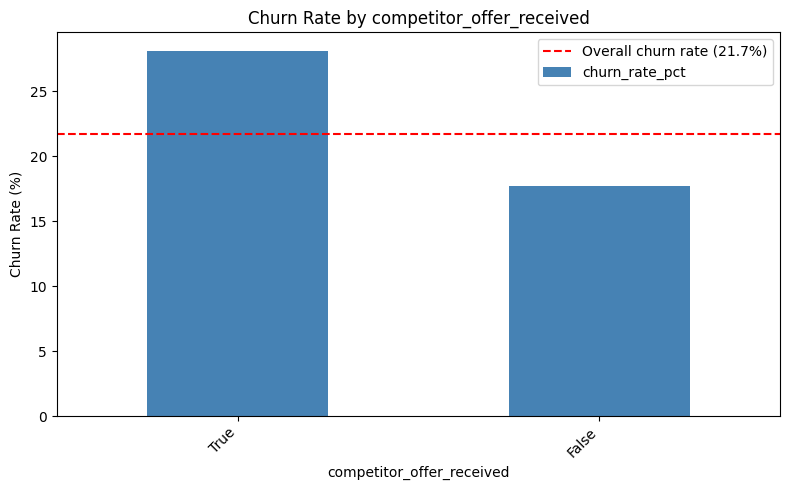

See per-variable chi-square results above. contract_type, auto_pay, and
competitor_offer_received are the strong, reliable categorical signals.


In [37]:
categorical_cols = [
    'contract_type',
    'plan_tier',
    'service_segment',
    'signup_channel',
    'primary_device',
    'payment_method',
    'has_family_plan',
    'auto_pay',
    'discount_offered',
    'competitor_offer_received'
]

category_results = {}

for col in categorical_cols:
    ct = churn_by_category(df, col)
    category_results[col] = ct
    plot_churn_rate_by_category(ct, col, overall_churn_rate)

## Reading these results: 10 chi-square tests were run above. At an uncorrected alpha=0.05,
## roughly one could come back "significant" by chance alone; a Bonferroni-adjusted
## threshold would be 0.05/10 = 0.005.
## contract_type, auto_pay, and competitor_offer_received clear that bar by a huge margin -
## contract_type in particular is the single strongest churn predictor found anywhere in
## this notebook (month-to-month churns far more than annual/two-year contracts).
## plan_tier and primary_device are borderline (p~0.01) and shouldn't be leaned on alone.
## service_segment, signup_channel, payment_method, has_family_plan, and discount_offered
## show no significant association with churn in this dataset.
print("See per-variable chi-square results above. contract_type, auto_pay, and")
print("competitor_offer_received are the strong, reliable categorical signals.")

--- tenure_group ---
churn           No  Yes  total  churn_rate_pct
tenure_group                                  
0-6            481  234    715           32.73
7-12           740  268   1008           26.59
13-24         1286  355   1641           21.63
25-48         1141  192   1333           14.40
49+            267   36    303           11.88

Chi-square = 124.30, p-value = 6.429e-26, dof = 4



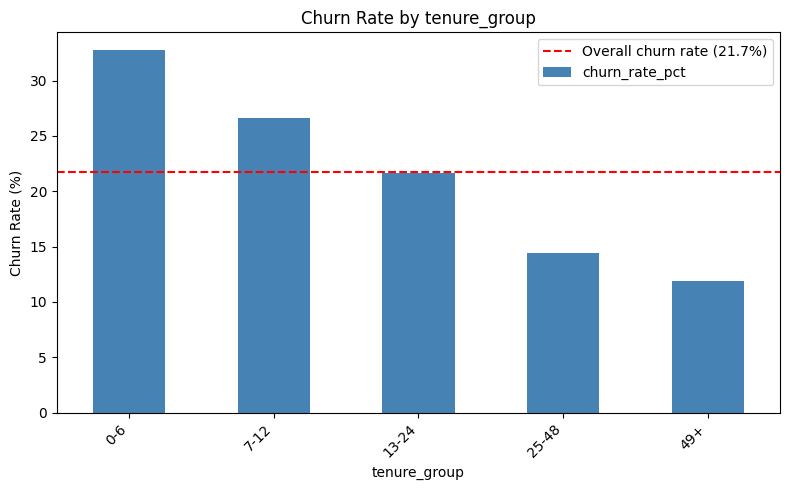

--- satisfaction_group ---
churn                 No  Yes  total  churn_rate_pct
satisfaction_group                                  
Low (<5)               9    8     17           47.06
Medium (5-8)        1405  608   2013           30.20
High (8-10)         2501  469   2970           15.79

Chi-square = 153.13, p-value = 5.592e-34, dof = 2



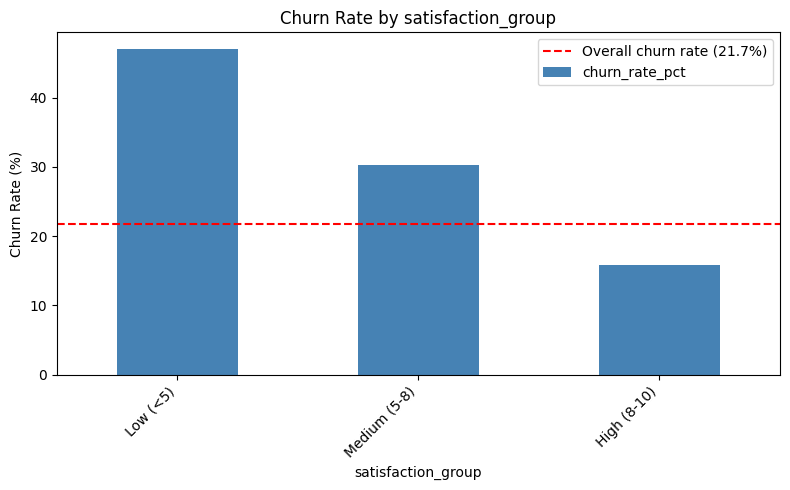

In [38]:
## Binned tenure and satisfaction (mutually-exclusive segments, matching the SQL script)
## The tenure analysis earlier in this notebook used CUMULATIVE thresholds (<=3, <=6, ...
## months) to build a targeting/lift curve. This reproduces the mutually-exclusive tenure
## bands from the SQL churn segmentation, which read more simply as "churn rate by segment."

tenure_bins = [-1, 6, 12, 24, 48, df['tenure_months'].max()]
tenure_labels = ['0-6', '7-12', '13-24', '25-48', '49+']
df['tenure_group'] = pd.cut(df['tenure_months'], bins=tenure_bins, labels=tenure_labels)

tenure_group_ct = churn_by_category(df, 'tenure_group')
plot_churn_rate_by_category(tenure_group_ct, 'tenure_group', overall_churn_rate)

satisfaction_bins = [0, 5, 8, 10.01]
satisfaction_labels = ['Low (<5)', 'Medium (5-8)', 'High (8-10)']
df['satisfaction_group'] = pd.cut(df['satisfaction_score'], bins=satisfaction_bins, labels=satisfaction_labels, right=False)

satisfaction_group_ct = churn_by_category(df, 'satisfaction_group')
plot_churn_rate_by_category(satisfaction_group_ct, 'satisfaction_group', overall_churn_rate)

## Note: the "Low" satisfaction bucket contains only ~17 customers - its churn rate is not
## a stable estimate (same small-sample issue as the high-payment-failure tail earlier).
## The Medium vs. High split (n~2,000-3,000 each) is the reliable part of this result.

In [39]:
## Do high-risk characteristics overlap in the same customers?
## Same question as the final query in Script-2.sql, completed here with an actual
## churn-rate calculation - the SQL version returned matching rows without aggregating one.

high_risk = (
    (df['satisfaction_score'] < 5) &
    (df['tenure_months'].between(0, 6)) &
    (df['contract_type'] == 'Month-to-month') &
    (~df['auto_pay'])
)

n_high_risk = high_risk.sum()
n_high_risk_churned = (high_risk & (df['churn'] == 'Yes')).sum()

print(f"Customers meeting ALL four risk criteria: {n_high_risk}")
if n_high_risk > 0:
    print(f"Of those, churned: {n_high_risk_churned} ({n_high_risk_churned / n_high_risk * 100:.2f}%)")
else:
    print("No customers meet all four criteria simultaneously.")

## Note: stacking four conditions with AND is extremely restrictive - only a handful of
## customers satisfy all of them at once, even though each condition individually flags a
## much larger at-risk group. This is the practical argument for a weighted risk score (or
## a real classification model in Phase 6) instead of requiring every risk factor to
## co-occur.

Customers meeting ALL four risk criteria: 2
Of those, churned: 1 (50.00%)


In [20]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nRows per customer:")
print(df.groupby('customer_id').size().describe())

print("\nCustomers with more than one record:")
print((df.groupby('customer_id').size() > 1).sum())

Shape: (5000, 31)

Columns:
['customer_id', 'age', 'service_segment', 'signup_channel', 'primary_device', 'tenure_months', 'contract_type', 'plan_tier', 'num_services', 'has_family_plan', 'monthly_charges', 'total_charges', 'payment_method', 'auto_pay', 'payment_failures_last_year', 'support_tickets_last_year', 'avg_resolution_hours', 'uses_mobile_app', 'app_logins_per_month', 'avg_session_minutes', 'monthly_usage_hours', 'days_since_last_login', 'email_open_rate_pct', 'satisfaction_score', 'nps_score', 'competitor_offer_received', 'price_increase_last_year_pct', 'discount_offered', 'discount_pct', 'referrals_made', 'churn']

First 5 rows:


,customer_id,age,service_segment,signup_channel,primary_device,tenure_months,contract_type,plan_tier,num_services,has_family_plan,...,days_since_last_login,email_open_rate_pct,satisfaction_score,nps_score,competitor_offer_received,price_increase_last_year_pct,discount_offered,discount_pct,referrals_made,churn
0,CX00001,37,Streaming,Referral,Mobile,16,Month-to-month,Premium,6,False,...,25,35.7,9.6,10,False,7.1,True,8.7,0,Yes
1,CX00002,28,Cloud Storage,Paid Social,Desktop,12,Annual,Plus,6,True,...,6,55.6,6.9,8,True,0.9,True,10.3,1,No
2,CX00003,49,Productivity,Organic Search,Tablet,4,Month-to-month,Standard,1,False,...,3,50.7,6.7,7,False,5.7,True,19.7,0,No
3,CX00004,42,Fintech,Email Campaign,Desktop,10,Month-to-month,Plus,8,False,...,28,39.6,7.7,9,False,2.7,False,0.0,1,Yes
4,CX00005,30,Fintech,Organic Search,Mobile,14,Month-to-month,Basic,1,True,...,5,62.3,6.5,9,False,2.2,False,0.0,0,Yes



Rows per customer:
count    5000.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64

Customers with more than one record:
0


In [19]:
for i, col in enumerate(df.columns, 1):
    print(i, col)

1 customer_id
2 age
3 service_segment
4 signup_channel
5 primary_device
6 tenure_months
7 contract_type
8 plan_tier
9 num_services
10 has_family_plan
11 monthly_charges
12 total_charges
13 payment_method
14 auto_pay
15 payment_failures_last_year
16 support_tickets_last_year
17 avg_resolution_hours
18 uses_mobile_app
19 app_logins_per_month
20 avg_session_minutes
21 monthly_usage_hours
22 days_since_last_login
23 email_open_rate_pct
24 satisfaction_score
25 nps_score
26 competitor_offer_received
27 price_increase_last_year_pct
28 discount_offered
29 discount_pct
30 referrals_made
31 churn
